##### Questions to be answered from this analysis

<span style="font-size:12px">

1. How do accident percentages vary by month, Do accident counts fluctuate and indicate seasonal patterns in the data?
2. What is the number of incidents on each day of the week and hour of the day, and during which time of the day are accidents the most frequent?
3. On which street do most number of accidents occur, and what percentage of the actual reported did that specific street account?
4. Which factor attributes to be the most common contributing factor for Vehicle 1, and more specifically, what is the most common contributing factor to the most serious incidents?
</span>


#### Libararies

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Dataset

In [3]:
#TODO: replace local link with github link so we users can work with code

#url = 'github_dataset_url'

#To be remove before being notebook is uploaded to github
data_path = r"C:\Users\ejiro\Documents\work_stuff\data\analysis\projects\personal_or_side_project\nyc_accident_analysis\cleaned\cleaned.csv" 

df = pd.read_csv(data_path)

In [4]:
df.head()

,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,cross_street_name,off_street_name,...,vehicle_type_code_1,vehicle_type_code_2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5,month_of_crash,day_of_crash,hour_of_crash,street_of_crash,is_fatal
0,2020-08-29,1900-01-01 15:40:00,BRONX,10466.0,40.89210,-73.833760,POINT (-73.83376 40.8921),PRATT AVENUE,STRANG AVENUE,NaN,...,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,Aug,Saturday,15,PRATT AVENUE,False
1,2020-08-29,1900-01-01 21:00:00,BROOKLYN,11221.0,40.69050,-73.919914,POINT (-73.919914 40.6905),BUSHWICK AVENUE,PALMETTO STREET,NaN,...,Sedan,Sedan,NaN,NaN,NaN,Aug,Saturday,21,BUSHWICK AVENUE,False
2,2020-08-29,1900-01-01 18:20:00,NaN,NaN,40.81650,-73.946556,POINT (-73.946556 40.8165),8 AVENUE,NaN,NaN,...,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,Aug,Saturday,18,8 AVENUE,False
3,2020-08-29,1900-01-01 00:00:00,BRONX,10459.0,40.82472,-73.892960,POINT (-73.89296 40.82472),NaN,NaN,1047 SIMPSON STREET,...,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Motorcycle,NaN,Aug,Saturday,0,NAN,False
4,2020-08-29,1900-01-01 17:10:00,BROOKLYN,11203.0,40.64989,-73.933890,POINT (-73.93389 40.64989),NaN,NaN,4609 SNYDER AVENUE,...,Sedan,Sedan,NaN,NaN,NaN,Aug,Saturday,17,NAN,False


#### Question 1: How do accident percentages vary by month, and are there distinct seasonal patterns in the data?

In [5]:
df["month_of_crash"].unique() # might delete cell

array(['Aug', 'Jul', 'Jun', 'May', 'Apr', 'Mar', 'Feb', 'Jan'],
      dtype=object)

In [6]:
df.sort_values("crash_date")["month_of_crash"].unique() # might delete cell

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug'],
      dtype=object)

In [7]:
month_order = df.sort_values("crash_date")["month_of_crash"].unique()
# first sorts the df by crash date, and then extract the unique month of crash, that was the array is in the right order

In [8]:
monthly_crash_pct = (
    (df["month_of_crash"].value_counts(normalize=True) * 100).reindex(month_order).round(2)
)

##### Result

In [9]:
monthly_crash_pct

month_of_crash
Jan    19.08
Feb    18.27
Mar    14.77
Apr     5.50
May     8.21
Jun    10.17
Jul    12.32
Aug    11.68
Name: proportion, dtype: float64

###### Visuals (Monthly Crash Percentage)

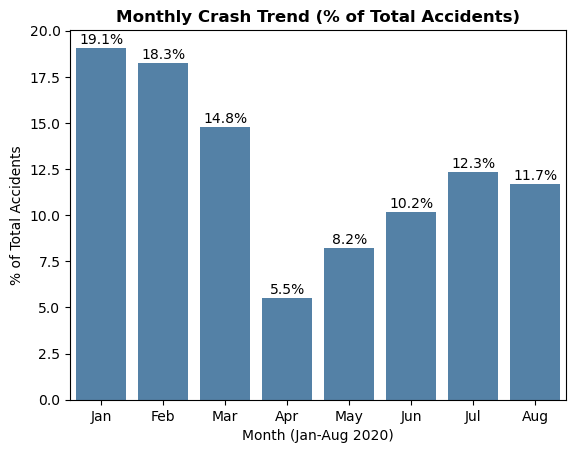

In [44]:
ax = sns.barplot(x=monthly_crash_pct.index, y=monthly_crash_pct.values, color='steelblue')

first_month = month_order[0]
last_month = month_order[-1]

plt.title("Monthly Crash Trend (% of Total Accidents)", fontweight='bold')
plt.xlabel(f'Month ({first_month}-{last_month} 2020)')
plt.ylabel('% of Total Accidents')


for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', 
        va='center',
        xytext=(0,6),
        textcoords='offset points',
    )

plt.savefig("monthly_crash_trend.png", dpi=300, bbox_inches="tight")

plt.show()

###### Insight from Data

<span style="font-size:12px"> 
Mid-period contraction is clearly evident in comparing the distribution of crashes on a calendar month basis for the period, indicating no normal seasonality. Winter months of January (19.1%) and February (18.3%) are responsible for close to 37.4% of total crashes during the period, being the most crash prone. Entering spring volume of crashes sharply declined hitting the absolute trough of 5.5% (reduction of 71.2% from January) in April. Recovery of crashes were ongoing from May (8.2%) through July (12.3%) stabilizing at 11.7% in August, although still lower than the crash level of start of year.
    </span>

###### Export Result for Visualization Tool

In [11]:
monthly_crash_pct.name = "percentage_of_crash"

In [12]:
monthly_crash_pct.to_csv("monthly_crash_pct.csv", index=True)

#### Question 2: How is accident frequency distributed by day of the week and hour of the day, and at what specific peak times do accidents occur most frequently?

In [13]:
day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [14]:
day_order

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [15]:
day_hour_matrix = (df.groupby(["day_of_crash", "hour_of_crash"]).size().unstack().reindex(day_order))

In [16]:
day_hour_matrix

hour_of_crash,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_crash,,,,,,,,,,,,,,,,,,,,,
Monday,385,200,126,112,117,142,310,407,591,552,...,682,690,746,736,658,494,373,325,278,219
Tuesday,333,134,88,96,78,159,294,433,643,576,...,719,654,799,750,693,509,444,326,339,264
Wednesday,367,154,129,106,103,176,258,407,563,509,...,741,730,756,743,688,520,402,378,366,259
Thursday,391,144,116,78,118,148,316,445,679,593,...,722,683,814,778,703,556,454,399,340,283
Friday,436,200,150,111,115,178,315,383,648,638,...,815,781,870,804,800,628,574,472,430,428
Saturday,526,330,259,232,212,180,193,223,323,330,...,722,602,668,624,628,569,484,455,439,419
Sunday,510,312,271,254,232,195,182,165,231,241,...,615,537,566,539,526,462,407,356,365,292


###### Peak Times Accident Occur Most Frequently

In [17]:
peak_window = df.groupby(["day_of_crash", "hour_of_crash"]).size().idxmax()

In [18]:
peak_window

('Friday', np.int64(16))

<function matplotlib.pyplot.show(close=None, block=None)>

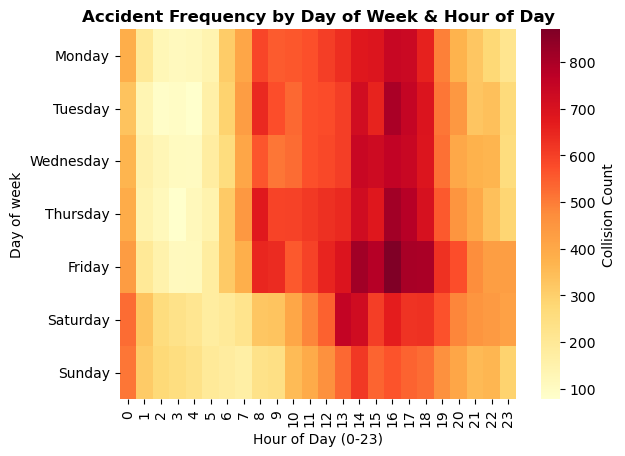

In [19]:
sns.heatmap(day_hour_matrix, cmap='YlOrRd', cbar_kws={'label': 'Collision Count'})

plt.title(
     'Accident Frequency by Day of Week & Hour of Day',
    fontweight='bold',
)

plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of week')


plt.savefig("accident_frequency.png", dpi=300, bbox_inches="tight")

plt.show

##### Insight from the data

<span style="font-size:12px"> 
Traffic accidents show a clearly defined dual peak, strongly correlating with urban commuting patterns. The primary risk window emerges during the late afternoon 14:00-18:00 homeward commute, peaking absolutely at Friday, 16:00 (4:00 PM), with 870 collisions. Friday is the riskiest day overall (12271 crashes total), due to the effects of afternoon rush-hour traffic and weekend travel transitions. Although morning rush hours 08:00-09:00 pose a second bump, afternoon volume is nearly 3x as large, indicating that evening commute conditions drive most day's crash risk.
</span>

###### Export Result for visualisation tool

In [20]:
day_hour_matrix_formatted = day_hour_matrix.reset_index().melt(id_vars="day_of_crash", 
                                var_name="hour_of_crash", 
                                value_name="crash_count")

In [21]:
day_hour_matrix_formatted

,day_of_crash,hour_of_crash,crash_count
0,Monday,0,385
1,Tuesday,0,333
2,Wednesday,0,367
3,Thursday,0,391
4,Friday,0,436
...,...,...,...
163,Wednesday,23,259
164,Thursday,23,283
165,Friday,23,428
166,Saturday,23,419


In [22]:
day_hour_matrix_formatted.to_csv("day_hour_matrix_formatted.csv", index=False)

#### Question 3: Which street recorded the highest number of accidents, and what percentage of total reported accidents occurred on that street?

In [23]:
df["on_street_name"].isna().any()

np.True_

In [24]:
valid_streets = df[
    df["on_street_name"].notna() & 
    ~df["on_street_name"].isin(['NAN', 'Unspecified', 'UNKNOWN', ''])
]["on_street_name"]
total_records = len(valid_streets)
street_counts = valid_streets.value_counts()
top_street = street_counts.index[0]
top_street_pct = round((street_counts.iloc[0] / total_records) * 100,2)

In [25]:
## group the valid streets and get their respective percentage

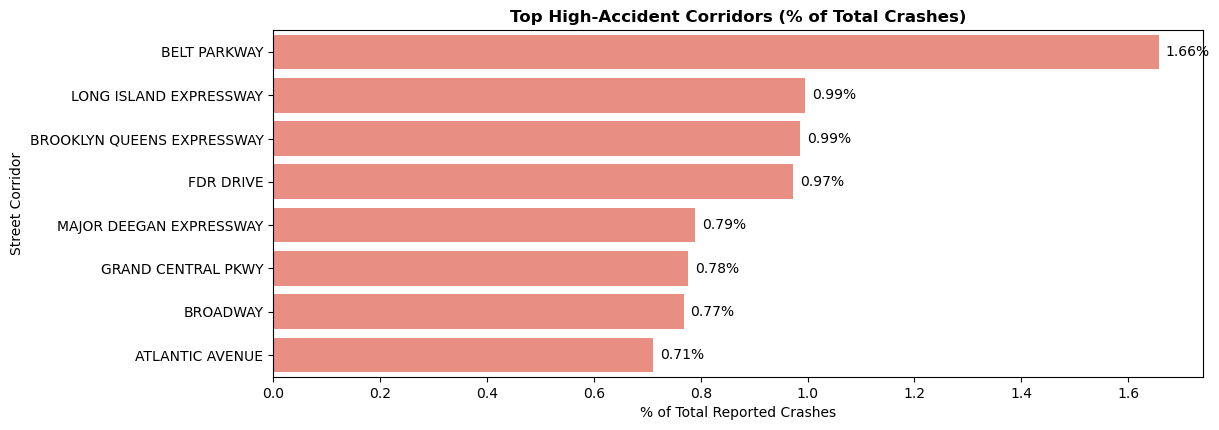

In [40]:
top_streets = (valid_streets.value_counts().head(8) / total_records) * 100

plt.figure(figsize=(12, 4.5))
ax = sns.barplot(x=top_streets.values, y=top_streets.index, color="salmon")

plt.title(
    'Top High-Accident Corridors (% of Total Crashes)',
    fontweight='bold',
)
plt.xlabel('% of Total Reported Crashes')
plt.ylabel('Street Corridor')

for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}%',
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
    )

plt.savefig("top_high_accident.png", dpi=300, bbox_inches="tight")
plt.show()

##### Insight from the data

<span style="font-size:12px"> 
Expressways top the list Belts Parkways alone causes nearly 1.7% of all crashes and accidents - topping the next highest (LE- 0.99%). High speed, multilane Parkways and Expressways pose the single highest spatially located risk in the dataset.
</span>

###### Export Result for visualisation tool

In [41]:
top_streets.to_csv("top_streets.csv", index=True)

#### Question 4: What is the primary contributing factor cited for Vehicle 1 across all reported accidents, and how does it compare to the leading factor in fatal accidents specifically?

In [28]:
valid_factors = df[
        ~df["contributing_factor_vehicle_1"].isin(
            ["Unspecified", np.nan, "NAN"]
        )
    ]
top_factor_overall = (
        valid_factors["contributing_factor_vehicle_1"]
        .value_counts()
        .idxmax()
    )

fatal_subset = valid_factors[valid_factors["is_fatal"] == True]
top_factor_fatal = (
        fatal_subset["contributing_factor_vehicle_1"].value_counts().idxmax()
    )
    

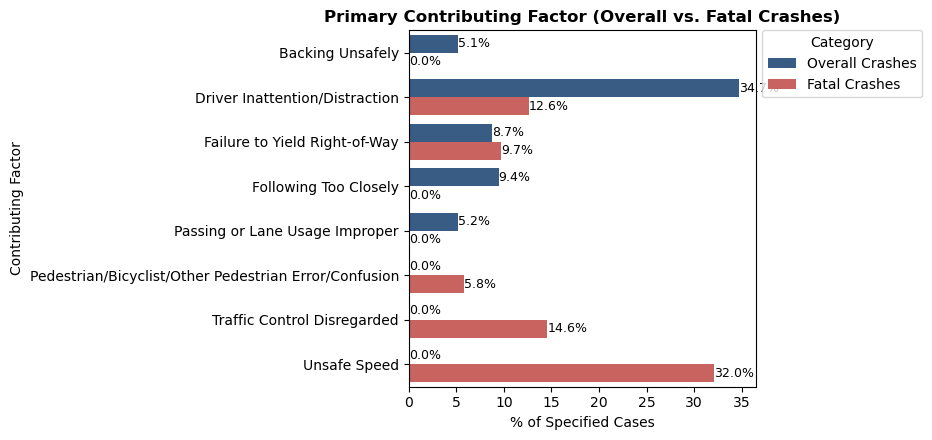

In [42]:
# 1. Filter out invalid factors
valid_factors = df[
    ~df["contributing_factor_vehicle_1"].isin(
        ["Unspecified", np.nan, "NAN", "Unknown"]
    )
]

# 2. Extract leading factor text variables
top_factor_overall = valid_factors["contributing_factor_vehicle_1"].value_counts().idxmax()

fatal_subset = valid_factors[valid_factors["is_fatal"] == True]
top_factor_fatal = fatal_subset["contributing_factor_vehicle_1"].value_counts().idxmax()

# 3. Calculate percentages using valid_factors (Fixes the chart data)
overall_f = (
    valid_factors['contributing_factor_vehicle_1']
    .value_counts(normalize=True)
    .head(5) * 100
)

fatal_f = (
    valid_factors[valid_factors['is_fatal']]['contributing_factor_vehicle_1']
    .value_counts(normalize=True)
    .head(5) * 100
)

# 4. Build visualization table & plot
comp_df = pd.DataFrame({'Overall Crashes': overall_f, 'Fatal Crashes': fatal_f}).fillna(0)
comp_df['Factor'] = comp_df.index
comp_melted = pd.melt(
    comp_df,
    id_vars=['Factor'],
    value_vars=['Overall Crashes', 'Fatal Crashes'],
    var_name='Crash Type',
    value_name='Percentage',
)

plt.figure(figsize=(9.5, 4.5))
ax = sns.barplot(
    x='Percentage',
    y='Factor',
    hue='Crash Type',
    data=comp_melted,
    palette=['#2b5c8f', '#d9534f'],
)

plt.title(
    'Primary Contributing Factor (Overall vs. Fatal Crashes)',
    fontweight='bold',
)
plt.xlabel('% of Specified Cases')
plt.ylabel('Contributing Factor')


plt.legend(
    title='Category',
    bbox_to_anchor=(1.02, 1),  
    loc='upper left',
    borderaxespad=0
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

plt.savefig("crash_factors.png", dpi=300, bbox_inches="tight")
plt.tight_layout()  
plt.show()


##### Insight from the data

<span style="font-size:12px"> 
The removal of these uninformative entries reveals that the most prominent cause of collisions overall is Driver Inattention/Distraction (34.7% of all recorded entries); however, that changes too. Unsafe speeds in Fatal accidents (32.0%) and traffic control Disregarded (14.6%). This tells us that, on the one hand, cognitive factors cause most collisions in urban roads, whilst issues concerning velocity or disregard for signaling are far worse about fatal accidents.
</span>

###### Export Result for visualisation tool

In [38]:
comp_df.to_csv("comp_df.csv")